# AI Programming Foundations — Data Workflow

**Student:** Maurizio Pinto  
**Dataset:** Titanic - Machine Learning from Disaster  
**Source:** https://www.kaggle.com/c/titanic/data  

This project builds a complete, reproducible data workflow using Python. I load the Titanic dataset, clean and transform it, perform exploratory analysis, create visualizations, and communicate findings. This workflow serves as the foundation for future ML, deep learning, and agentic AI projects in the capstone.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## Data Ingestion

In [2]:
df = pd.read_csv("dataset/train.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Data Cleaning

**Why cleaning is necessary:** The raw dataset has three quality issues that must be addressed before analysis. The Age column has 177 missing values (19.9%), which would exclude nearly one-fifth of passengers from any age-based analysis. The Cabin column is 77.1% missing, making it too sparse to impute reliably. The Embarked column has 2 missing entries. Additionally, PassengerId, Name, and Ticket are identifiers that do not carry analytical value for exploratory analysis. The cleaning functions below address these issues: the first fills missing ages using group medians to preserve the relationship between age, class, and sex; the second removes the unsalvageable Cabin column, fills the two Embarked gaps, and drops non-analytical columns.

In [5]:
def fill_missing_age(df: pd.DataFrame) -> pd.DataFrame:
    """Fill missing Age values using median age grouped by Pclass and Sex.

    Grouping by passenger class and sex preserves the correlation between
    these variables and age, producing more accurate imputations than a
    simple global median.

    Parameters
    ----------
    df : pd.DataFrame
        Titanic dataset with columns 'Age', 'Pclass', and 'Sex'.

    Returns
    -------
    pd.DataFrame
        DataFrame with all missing Age values filled.
    """
    df = df.copy()
    df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
        lambda x: x.fillna(x.median())
    )
    return df


def clean_cabin_and_embarked(df: pd.DataFrame) -> pd.DataFrame:
    """Drop sparse columns, fill Embarked, and remove non-analytical columns.

    Drops the Cabin column due to excessive missingness (~77%), fills the
    two missing Embarked values with the mode, and removes PassengerId,
    Name, and Ticket as they do not contribute to exploratory analysis.

    Parameters
    ----------
    df : pd.DataFrame
        Titanic dataset after age imputation.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with only analytically useful columns.
    """
    df = df.copy()
    df = df.drop(columns=["Cabin"])
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    df = df.drop(columns=["PassengerId", "Name", "Ticket"])
    return df

In [6]:
print(f"Before cleaning: {df.shape}")
print(df.isnull().sum())
print()

df = fill_missing_age(df)
df = clean_cabin_and_embarked(df)

print(f"After cleaning: {df.shape}")
print(df.isnull().sum())
df.head()

Before cleaning: (891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After cleaning: (891, 8)
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Exploratory Data Analysis

In [7]:
def explore_data(df: pd.DataFrame) -> dict:
    """Run exploratory analysis on the cleaned Titanic dataset.

    Produces summary statistics, survival rate breakdowns by key
    demographic groups, a correlation matrix for numeric columns,
    and age distribution statistics stratified by survival status.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned Titanic dataset.

    Returns
    -------
    dict
        Dictionary containing DataFrames for each analysis result.
    """
    results = {}

    results["summary_stats"] = df.describe()
    results["survival_by_class"] = df.groupby("Pclass")["Survived"].mean()
    results["survival_by_sex"] = df.groupby("Sex")["Survived"].mean()
    results["survival_by_embarked"] = df.groupby("Embarked")["Survived"].mean()
    results["correlation"] = df.select_dtypes(include=[np.number]).corr()
    results["age_by_survival"] = df.groupby("Survived")["Age"].describe()

    return results

In [8]:
results = explore_data(df)

print("=== Summary Statistics ===")
display(results["summary_stats"])

print("\n=== Survival Rate by Passenger Class ===")
print(results["survival_by_class"])

print("\n=== Survival Rate by Sex ===")
print(results["survival_by_sex"])

print("\n=== Survival Rate by Embarkation Port ===")
print(results["survival_by_embarked"])

print("\n=== Age Statistics by Survival ===")
display(results["age_by_survival"])

print("\n=== Correlation Matrix ===")
display(results["correlation"])

=== Summary Statistics ===


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== Survival Rate by Passenger Class ===
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

=== Survival Rate by Sex ===
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

=== Survival Rate by Embarkation Port ===
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

=== Age Statistics by Survival ===


,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,29.737705,12.818264,1.00,22.0,25.0,37.0,74.0
1,342.0,28.108684,14.010565,0.42,21.0,27.0,36.0,80.0



=== Correlation Matrix ===


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.059579,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.413583,0.083081,0.018443,-0.549500
Age,-0.059579,-0.413583,1.000000,-0.249854,-0.175526,0.122692
SibSp,-0.035322,0.083081,-0.249854,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.175526,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.122692,0.159651,0.216225,1.000000


## Visualizations

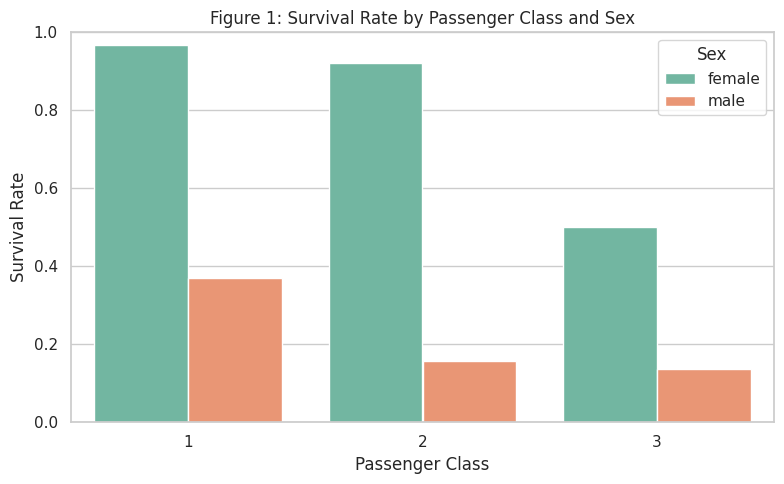

In [9]:
# Figure 1: Survival Rate by Passenger Class and Sex
survival_rates = df.groupby(["Pclass", "Sex"])["Survived"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=survival_rates,
    x="Pclass",
    y="Survived",
    hue="Sex",
    palette="Set2",
    ax=ax,
)
ax.set_title("Figure 1: Survival Rate by Passenger Class and Sex")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("figure1_survival_by_class_sex.png", dpi=150)
plt.show()

**Figure 1 Interpretation:** Female passengers had significantly higher survival rates than male passengers across all classes. First-class females had the highest survival rate (~97%), while third-class males had the lowest (~14%). Class and gender together strongly influenced survival outcomes.

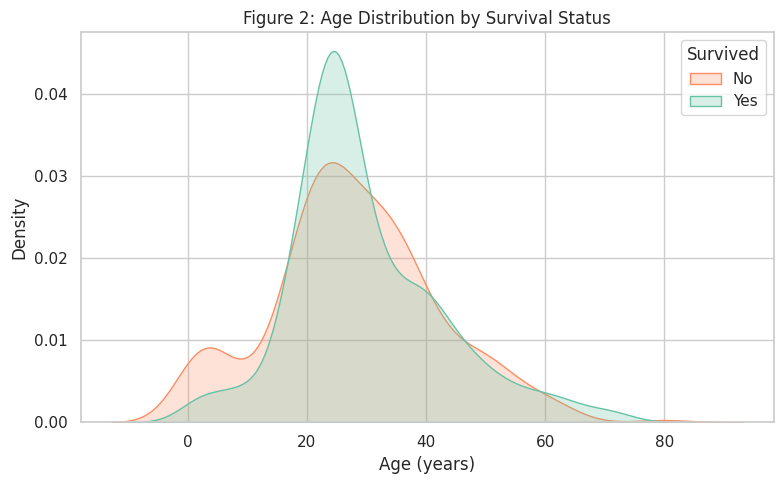

In [10]:
# Figure 2: Age Distribution by Survival Status
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(
    data=df,
    x="Age",
    hue="Survived",
    fill=True,
    common_norm=False,
    palette="Set2",
    ax=ax,
)
ax.set_title("Figure 2: Age Distribution by Survival Status")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig("figure2_age_by_survival.png", dpi=150)
plt.show()

**Figure 2 Interpretation:** Children (ages 0–10) show a distinct survival advantage compared to other age groups. The distributions for survivors and non-survivors are otherwise similar, peaking around age 20–30. This suggests that the "women and children first" protocol was applied during evacuation.

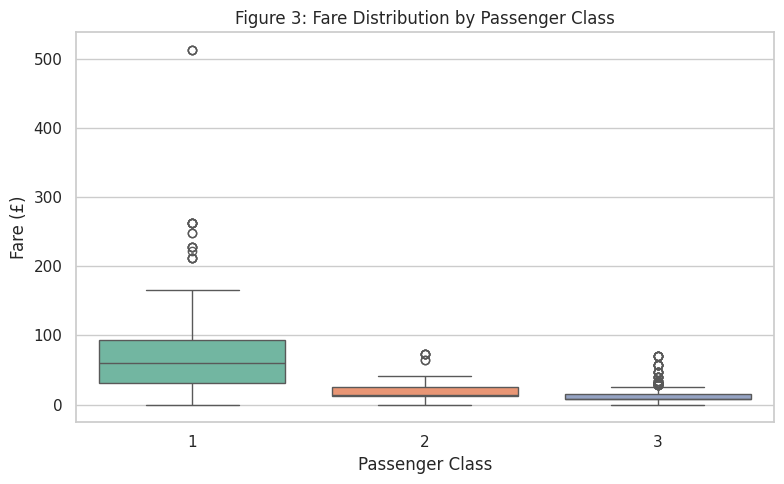

In [11]:
# Figure 3: Fare Distribution by Passenger Class
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Pclass",
    palette="Set2",
    ax=ax,
    legend=False,
)
ax.set_title("Figure 3: Fare Distribution by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Fare (£)")
plt.tight_layout()
plt.savefig("figure3_fare_by_class.png", dpi=150)
plt.show()

**Figure 3 Interpretation:** First-class fares were substantially higher and more variable than second and third class. First class has several outliers above £200, with one fare exceeding £500. The economic stratification visible here aligns with the survival advantage observed in Figure 1, as wealthier passengers had better cabin locations and earlier access to lifeboats.

## Summary and Interpretation

This analysis of the Titanic dataset revealed several key patterns:

**Key Insights**
- **Gender was the strongest survival predictor.** Female passengers survived at much higher rates than males across all classes (e.g., ~97% vs ~37% in first class).
- **Class mattered significantly.** First-class passengers had a survival rate of approximately 63%, compared to ~47% for second class and ~24% for third class.
- **Children were prioritized.** The age distribution shows a clear survival advantage for passengers under 10, consistent with evacuation protocols.
- **Fare reflects economic stratification.** First-class fares were dramatically higher with large outliers, correlating with both cabin location and survival.

**Limitations**
- The test set does not include the `Survived` column, so this analysis is limited to the 891 training passengers only.
- The `Cabin` column was dropped due to 77% missingness, removing potentially useful deck-location information.
- Age imputation by group median may mask individual variation and could introduce bias if the missingness pattern is not random.
- This dataset captures only a subset of passengers and crew; the full passenger manifest is larger.

**Surprising Observations**
- Embarkation port shows a survival difference (Cherbourg passengers survived at higher rates), which likely reflects class composition rather than a direct effect of the port itself.
- The wide spread of first-class fares suggests economic diversity even within the highest class.